
# Stream Macroinvertebrates Image Classification Using MobileNet, EfficientNet  and Vision Transformer Models
# ==================================
### This notebook demonstrates how to:
### 1. Load your dataset organized by class folders (without predefined splits)
### 2. Perform train/validation split in code
### 3. Augment data during training
### 4. Build transfer learning model with **MobileNet**,  **EfficientNet** and **Vision Transformer Model** pretrained on ImageNet
### 5. Train, evaluate, and predict on new images


In [ ]:
%cd /content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/

/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



## Step 0: Data Preparation
  
1.   Set the run time to one of the GPU options by selecting Runtime/Change Runtime type/...

2. Set the working folder for google colab notebook to the folder in the google drive.

3. Download stream invertebrates dataset from Kaggle (https://www.kaggle.com/datasets/kennethtm/stream-macroinvertebrates/data ) and unzip it in google drive folder. You will find stream macroinvertebrates dataset in the unzipped archive folder ( You can do this outside colab as well).

4. Manually create a insects_dataset folder in Assets folder.

5. The images for each insect species in a separate folder, with folder name as the species name.

6. Pick any three insect species from the unzipped archive folder. The three species you select need to be other than the three species shown in this demo.

6. Create two new folders train_data and test_data in insects_dataset folder you just created in Step 4.

7. Move five images from each species you have selected into the test_data folder. Please note that they need to be moved, not copied. In total you would have 15 images in the test_data folder (5 images corresponding to each species).

8. Move remaining folders into train_data folder. Please note that you will not move each image, but move each folder containing remaining images into the train_data folder. After moving you will see three folders in train_data folder, with each folder containing several insect images corresponding to each insect species.



In [ ]:
! kaggle datasets download -d kennethtm/stream-macroinvertebrates
!unzip /content/stream-macroinvertebrates.zip

Dataset URL: https://www.kaggle.com/datasets/kennethtm/stream-macroinvertebrates
License(s): CC-BY-NC-SA-4.0
100% 757M/757M [00:54<00:00, 14.7MB/s]

unzip:  cannot find or open /content/stream-macroinvertebrates.zip, /content/stream-macroinvertebrates.zip.zip or /content/stream-macroinvertebrates.zip.ZIP.


In [ ]:
#!unzip stream-macroinvertebrates.zip

Archive:  stream-macroinvertebrates.zip
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-0-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-1-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-10-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-100-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-101-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-102-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-103-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-104-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-105-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-106-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-107-t.png  
  inflating: stream_macroinvertebrates/Asellus sp/CPH-Asellus sp.-108-t.png  
  inflating: stream_macroinve

**1. Mobile-Net Model**

In [ ]:
#Step 1
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# === USER VARIABLES ===

# Path to your dataset folder organized by class subfolders
#DATASET_DIR = 'dataset/'  # Change to your dataset path
DATASET_DIR = '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'
# Image input size and batch size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # For deterministic shuffling/splitting

# === STEP 1: Load dataset and split into train/validation ===

print("Loading dataset with 80/20 train-validation split...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")




Loading dataset with 80/20 train-validation split...
Found 42 files belonging to 3 classes.
Using 34 files for training.
Found 42 files belonging to 3 classes.
Using 8 files for validation.
Classes found: ['Leptophlebiidae sp', 'Leuctra sp', 'Limnius sp']


In [ ]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

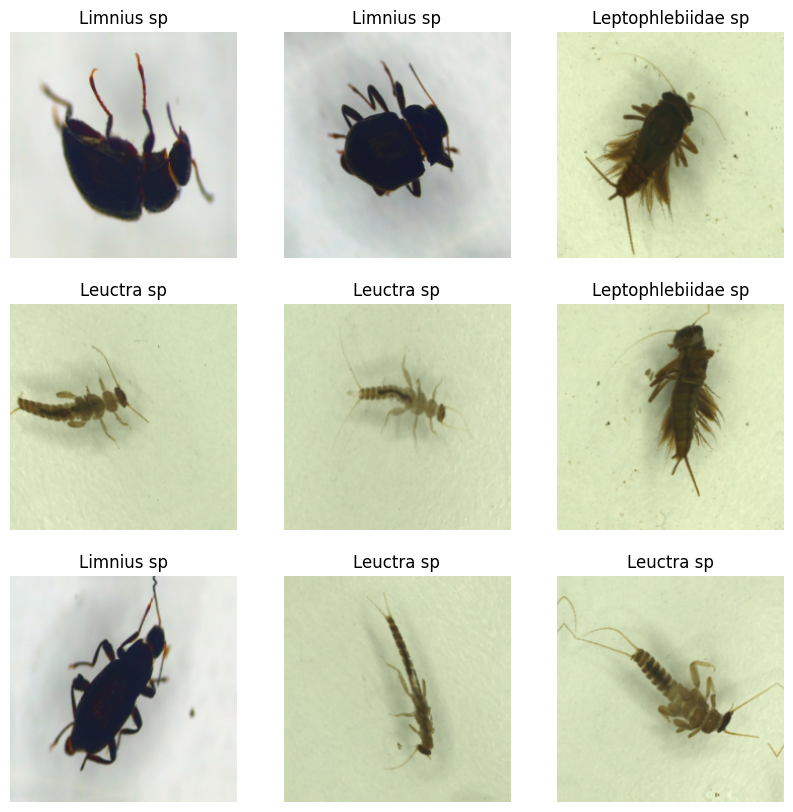

In [ ]:
# === STEP 3: Data augmentation (recommended) ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
# === STEP 4: Build transfer learning model ===

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze the base model initially

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.2353 - loss: 1.2846 - val_accuracy: 0.5000 - val_loss: 1.1921
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5000 - loss: 1.0501 - val_accuracy: 0.5000 - val_loss: 1.0494
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5294 - loss: 0.9873 - val_accuracy: 0.6250 - val_loss: 0.9400
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7353 - loss: 0.7880 - val_accuracy: 0.6250 - val_loss: 0.8527
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6471 - loss: 0.7653 - val_accuracy: 0.7500 - val_loss: 0.7740
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7647 - loss: 0.5940 - val_accuracy: 0.8750 - val_loss: 0.7130
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7353 - loss: 0.5664 - val_accuracy: 0.8750 - val_loss: 0.6501
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9118 - loss: 0.4087 - val_accuracy: 0.8750 - val_loss: 0

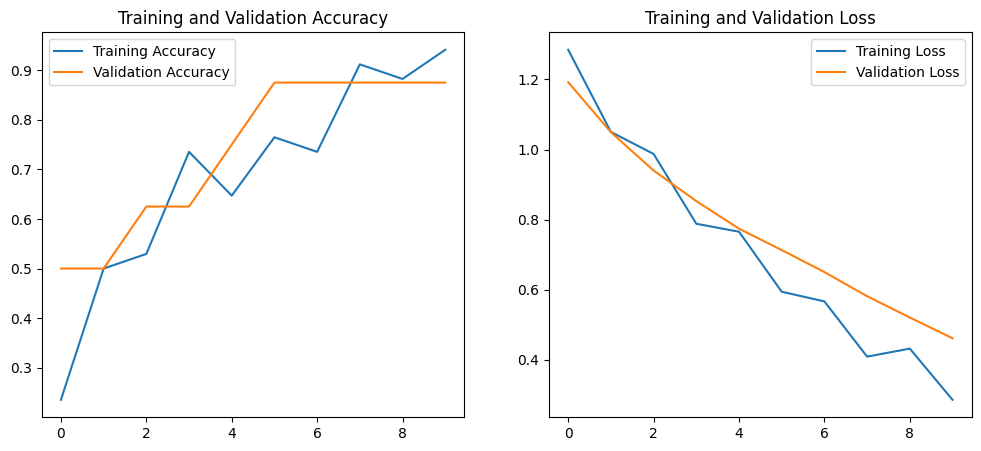

In [ ]:
# === STEP 6: Plot training curves ===

# Re-extracting from history to ensure correct length for initial EPOCHS
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# === STEP 7: Evaluate on validation set ===

val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8750 - loss: 0.4613
Validation accuracy: 87.50%


In [ ]:
# === STEP 9: Save the trained model ===
%cd /content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species/Trained data
model.save('macroinvertebrates_classifier.h5')
print("Model saved as 'macroinvertebrates_classifier.h5'")

/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species/Trained data
Model saved as 'macroinvertebrates_classifier.h5'


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


<Figure size 1200x1200 with 0 Axes>

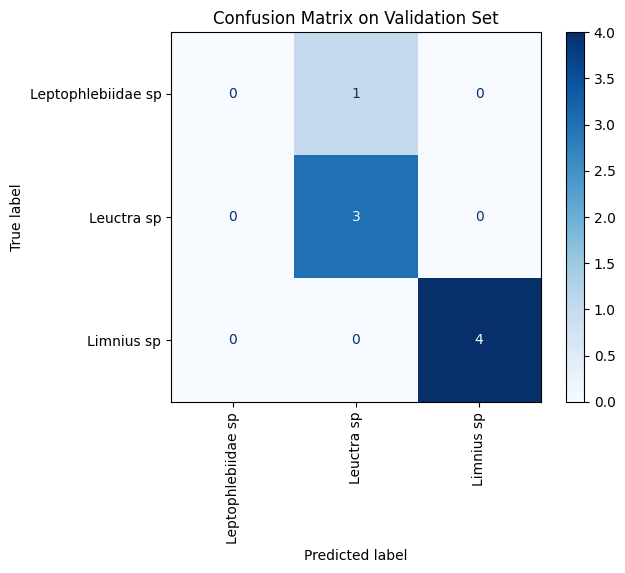

Weighted Precision: 0.7812
Weighted Recall:    0.8750
Weighted F1-score:  0.8214


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


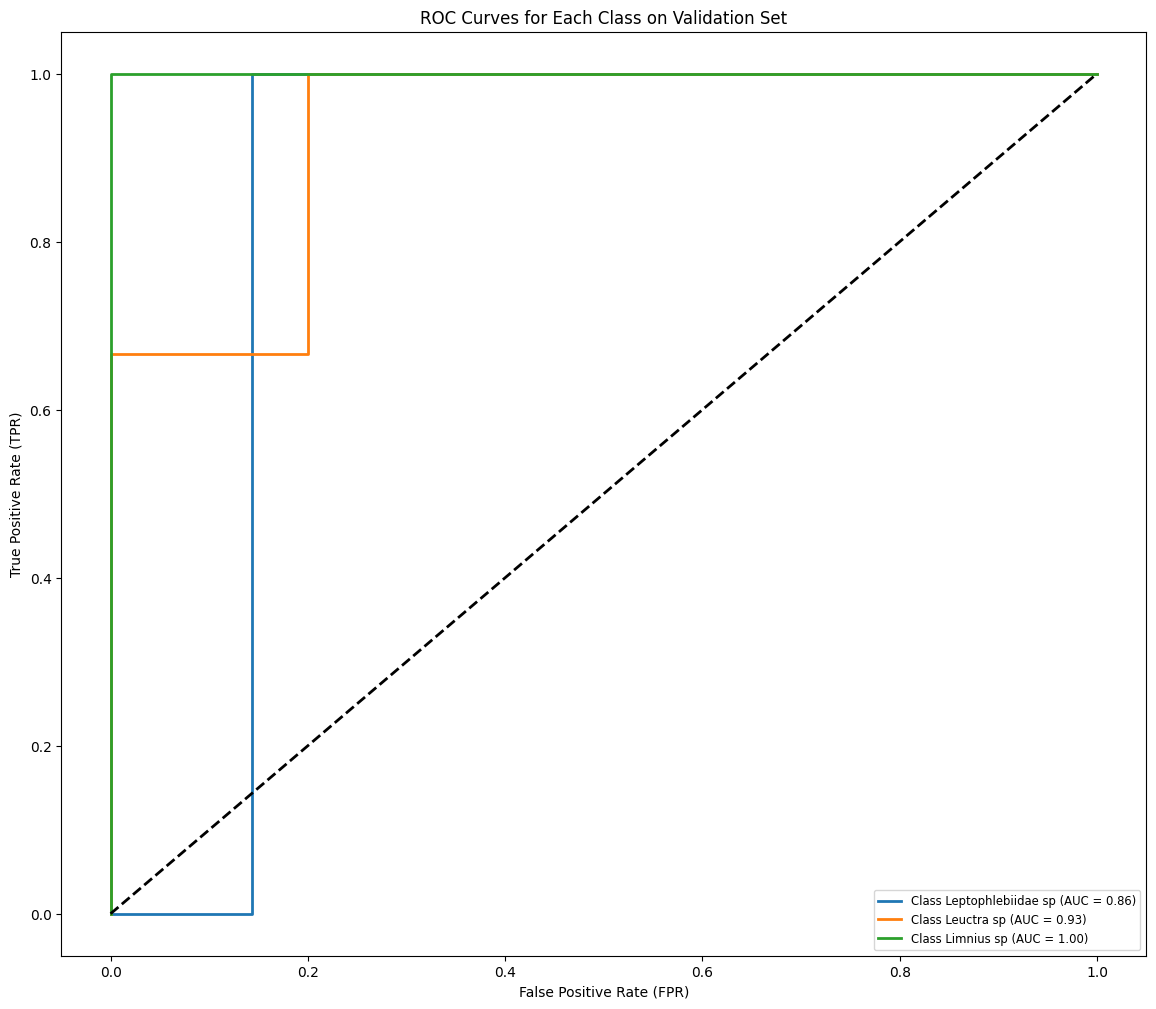

In [ ]:
# === STEP 10: Evaluate model with confusion matrix, precision, recall, F1-score ===

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

# Step 10.1: Aggregate predictions and true labels from validation dataset
y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# Step 10.2: Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Step 10.3: Precision, Recall, F1-score (weighted average)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

# Step 10.4: Multi-class ROC curves and AUC

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()



In [ ]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'. Please add some images and rerun.


**2. EfficientNet Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os


In [ ]:
DATASET_DIR = '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'

In [ ]:
IMG_SIZE = (224, 224)        # EfficientNetB0 default input size
BATCH_SIZE = 32
SEED = 123

In [ ]:
# === STEP 1: Load dataset with 80/20 train-validation split ===

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 42 files belonging to 3 classes.
Using 34 files for training.
Found 42 files belonging to 3 classes.
Using 8 files for validation.
Classes: ['Leptophlebiidae sp', 'Leuctra sp', 'Limnius sp']


In [ ]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

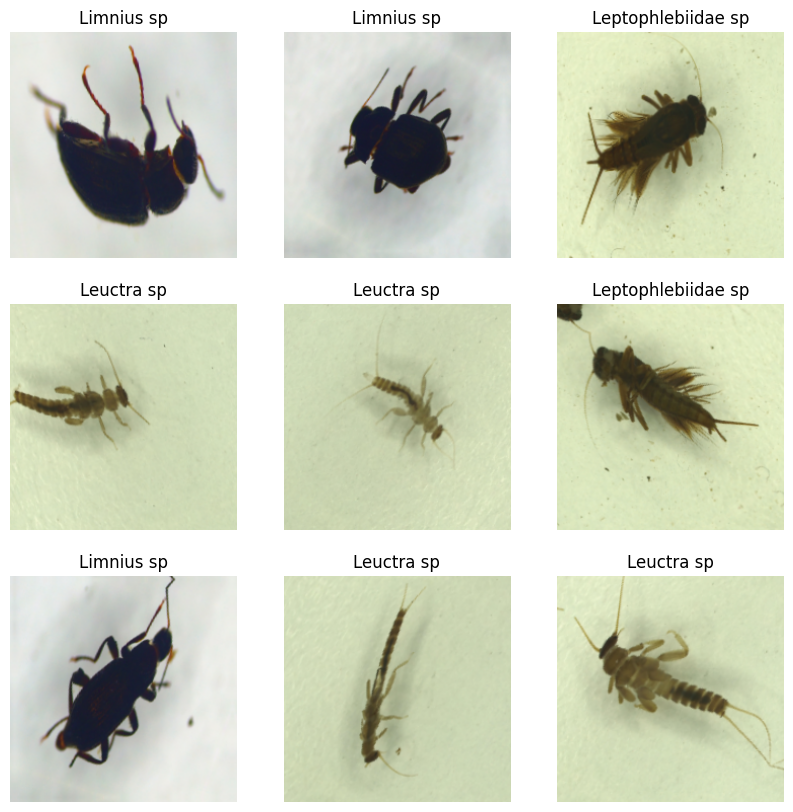

In [ ]:
# === STEP 3: Data augmentation ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Optional: visualize augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [ ]:
# === STEP 4: Build transfer learning model with EfficientNetB0 ===

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze base

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)               # apply augmentation
x = tf.keras.applications.efficientnet.preprocess_input(x)  # preprocess as EfficientNet expects
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.5588 - loss: 0.9558 - val_accuracy: 0.8750 - val_loss: 0.8172
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 0.5588 - loss: 0.9377 - val_accuracy: 1.0000 - val_loss: 0.7222
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.7941 - loss: 0.8197 - val_accuracy: 1.0000 - val_loss: 0.6344
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8824 - loss: 0.6646 - val_accuracy: 1.0000 - val_loss: 0.5562
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7647 - loss: 0.7217 - val_accuracy: 1.0000 - val_loss: 0.4854
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8529 - loss: 0.6114 - val_accuracy: 1.0000 - val_loss: 0.4257
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8529 - loss: 0.5838 - val_accuracy: 1.0000 - val_loss: 0.3804
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8824 - loss: 0.5046 - val_accuracy: 1.0000 - val_loss: 0

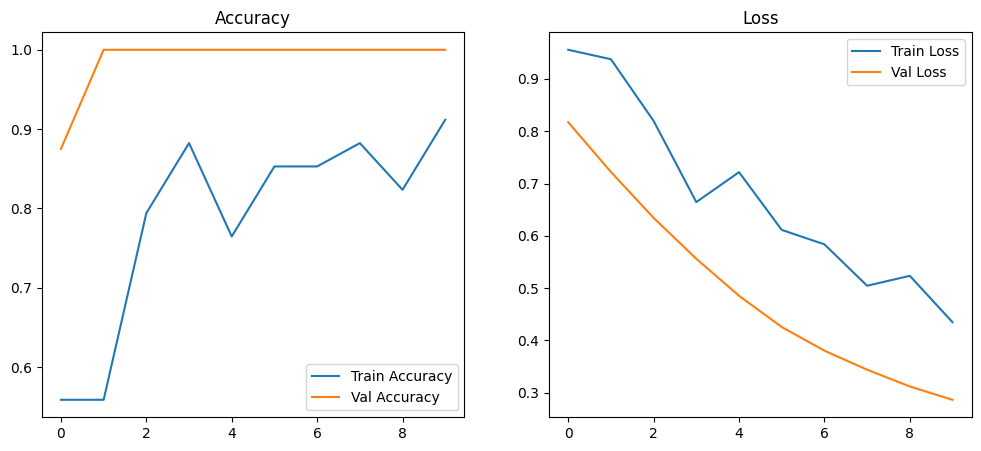

In [ ]:
# === STEP 6: Plot training curves ===

acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.8529 - loss: 0.6995 - val_accuracy: 1.0000 - val_loss: 0.2828
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.7353 - loss: 0.7760 - val_accuracy: 1.0000 - val_loss: 0.2793
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.7353 - loss: 0.6956 - val_accuracy: 1.0000 - val_loss: 0.2774
Epoch 13/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.7647 - loss: 0.7266 - val_accuracy: 1.0000 - val_loss: 0.2742
Epoch 14/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.7353 - loss: 0.6908 - val_accuracy: 1.0000 - val_loss: 0.2723
Epoch 15/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.7353 - loss: 0.6960 - val_accuracy: 1.0000 - val_loss: 0.2703
Epoch 16/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - accuracy: 0.7353 - loss: 0.6972 - val_accuracy: 1.0000 - val_loss: 0.2688
Epoch 17/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.8235 - loss: 0.6264 - val_accuracy: 1.0000 - val

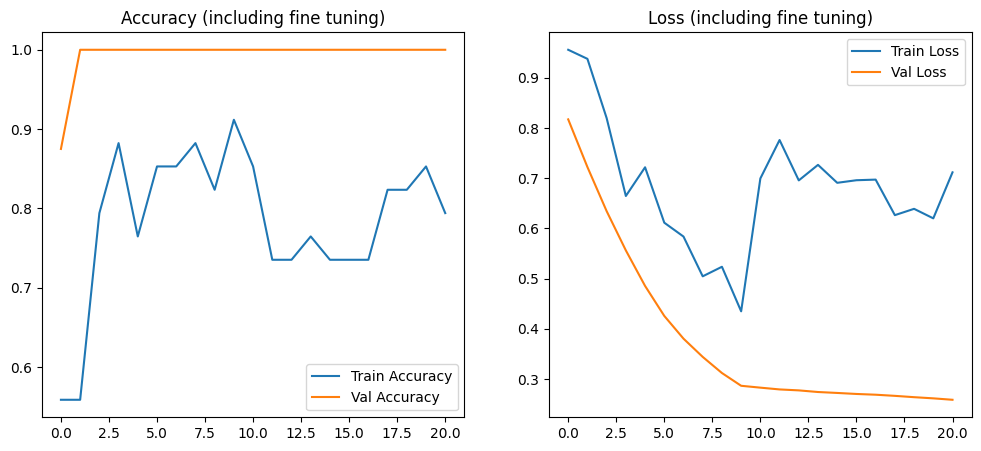

In [ ]:
# === STEP 7 (Optional): Fine-tune base model ===

base_model.trainable = True

# Freeze initial layers, train last layers of EfficientNet
fine_tune_at = 100  # Freeze all layers before this
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)

# Plot fine-tuning results (optional)
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy (including fine tuning)')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss (including fine tuning)')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


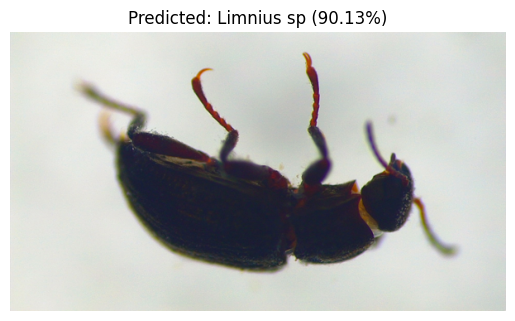

In [ ]:
# === STEP 8: Prediction on new images ===

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    return img_array

def predict_image(img_path, model, class_names):
    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]
    return class_names[pred_idx], confidence

# Example usage:
test_img_path = '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Test image/Copy of CPH-Limnius sp.-2203-v.png'  # replace with your test image path
predicted_class, confidence = predict_image(test_img_path, model, class_names)

plt.imshow(image.load_img(test_img_path))
plt.title(f'Predicted: {predicted_class} ({confidence * 100:.2f}%)')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


<Figure size 1200x1200 with 0 Axes>

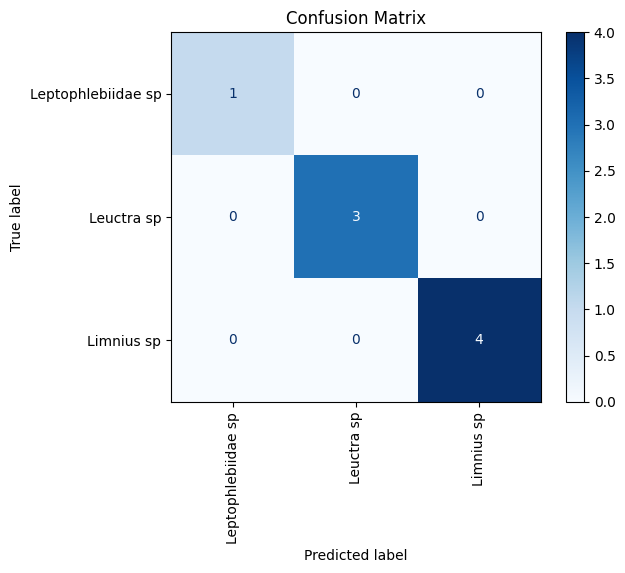

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


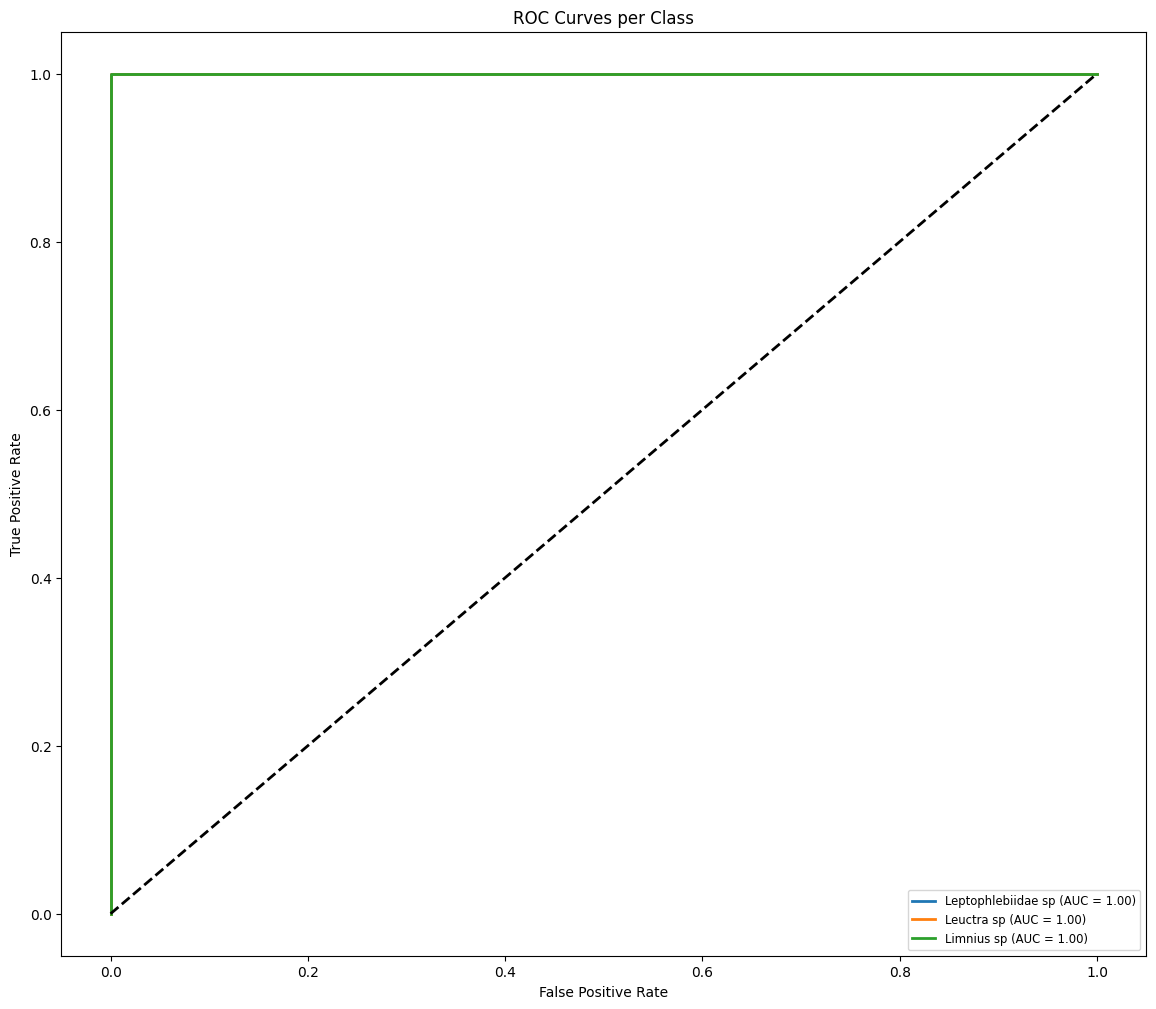

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf

# Aggregate true labels and predictions from validation dataset
y_true = []
y_pred = []
y_score = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall and F1-score
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'  # options: 'micro', 'macro', None...
)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# ROC Curve and AUC for multi-class
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Class')
plt.legend(loc='lower right', fontsize='small')
plt.show()


In [ ]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'. Please add some images and rerun.


**3. Vision Transformer Model**

In [ ]:
#!pip install tensorflow tensorflow-hub tensorflow-datasets matplotlib


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# === User parameters ===
DATASET_DIR = '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'  # Your insect dataset folder organized by classes
IMG_SIZE = 224            # ViT input size
BATCH_SIZE = 32
SEED = 123
EPOCHS = 10

In [ ]:

# === Step 1: Load Dataset with 80/20 split ===

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


Found 42 files belonging to 3 classes.
Using 34 files for training.
Found 42 files belonging to 3 classes.
Using 8 files for validation.
Classes: ['Leptophlebiidae sp', 'Leuctra sp', 'Limnius sp']


In [ ]:
# === Step 2: Data augmentation ===

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
# === Step 3: Load ViT Feature Extractor from TF Hub ===

vit_url = "https://tfhub.dev/sayakpaul/vit_b16_fe/1"
vit_layer = hub.KerasLayer(vit_url, trainable=False)

In [ ]:
#====Step 4:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Data augmentation
x = data_augmentation(inputs)

# The TF Hub ViT module expects pixel values in [0, 255].
# image_dataset_from_directory typically outputs float32 in [0, 255],
# and data_augmentation maintains this. So, no explicit [0,1] scaling is needed here.

# ViT feature extractor
# Wrap the vit_layer call in a Lambda layer to ensure proper symbolic tensor handling
features = tf.keras.layers.Lambda(lambda y: vit_layer(y))(x);

# Classification head
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(features)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:

# === Step 5: Train the model ===

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.4412 - loss: 1.3950 - val_accuracy: 0.5000 - val_loss: 1.1424
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - accuracy: 0.4706 - loss: 1.1133 - val_accuracy: 0.5000 - val_loss: 1.0371
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.6471 - loss: 0.8976 - val_accuracy: 0.5000 - val_loss: 0.9905
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step - accuracy: 0.6765 - loss: 0.8610 - val_accuracy: 0.7500 - val_loss: 0.9139
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.7941 - loss: 0.6889 - val_accuracy: 0.6250 - val_loss: 0.9206
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 0.7647 - loss: 0.7105 - val_accuracy: 0.7500 - val_loss: 0.8299
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 0.7353 - loss: 0.6166 - val_accuracy: 0.8750 - val_loss: 0.6697
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.8529 - loss: 0.5606 - val_accuracy: 0.8750 - val_loss: 0

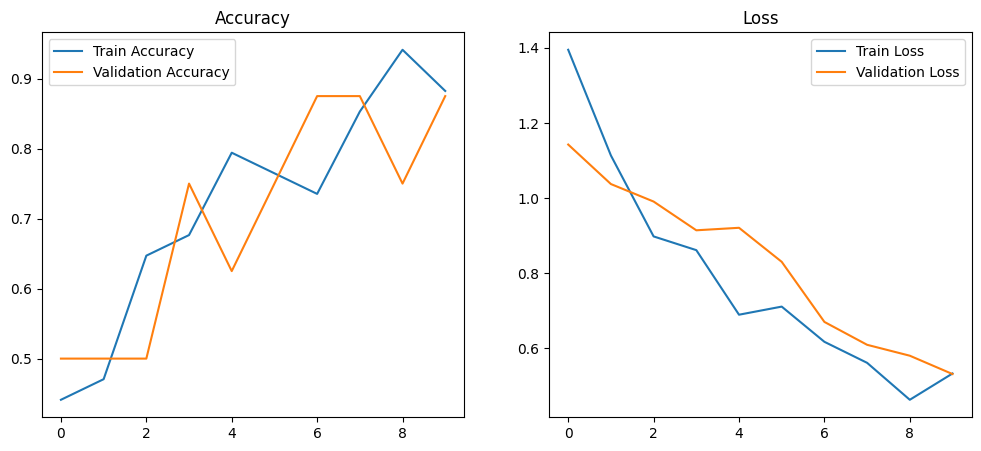

In [ ]:
# === Step 6: Plot training & validation accuracy/loss ===

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [ ]:
# === Step 7: Prediction helper function ===

def load_and_preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img_array

def predict_image(img_path, model, class_names):
    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    confidence = preds[0][pred_idx]
    return class_names[pred_idx], confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


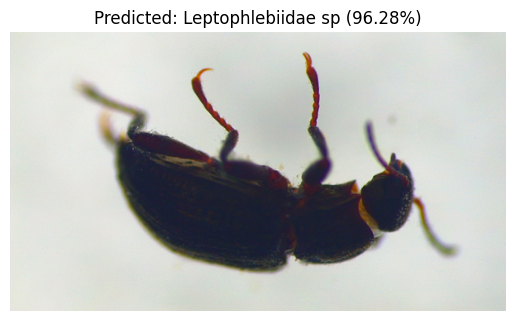

In [ ]:
# === Example prediction ===
test_img_path = '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Test image/Copy of CPH-Limnius sp.-2203-v.png'  # Replace with your image path

predicted_class, confidence = predict_image(test_img_path, model, class_names)

plt.imshow(tf.keras.preprocessing.image.load_img(test_img_path))
plt.title(f'Predicted: {predicted_class} ({confidence*100:.2f}%)')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


<Figure size 1200x1200 with 0 Axes>

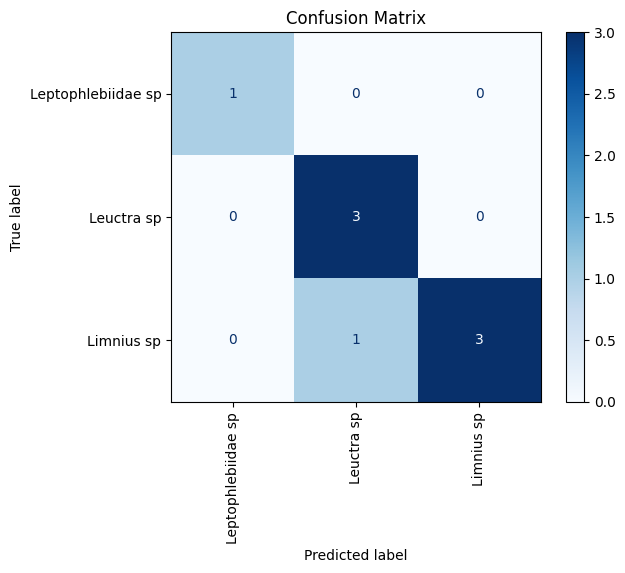

Precision: 0.9062
Recall:    0.8750
F1-score:  0.8750


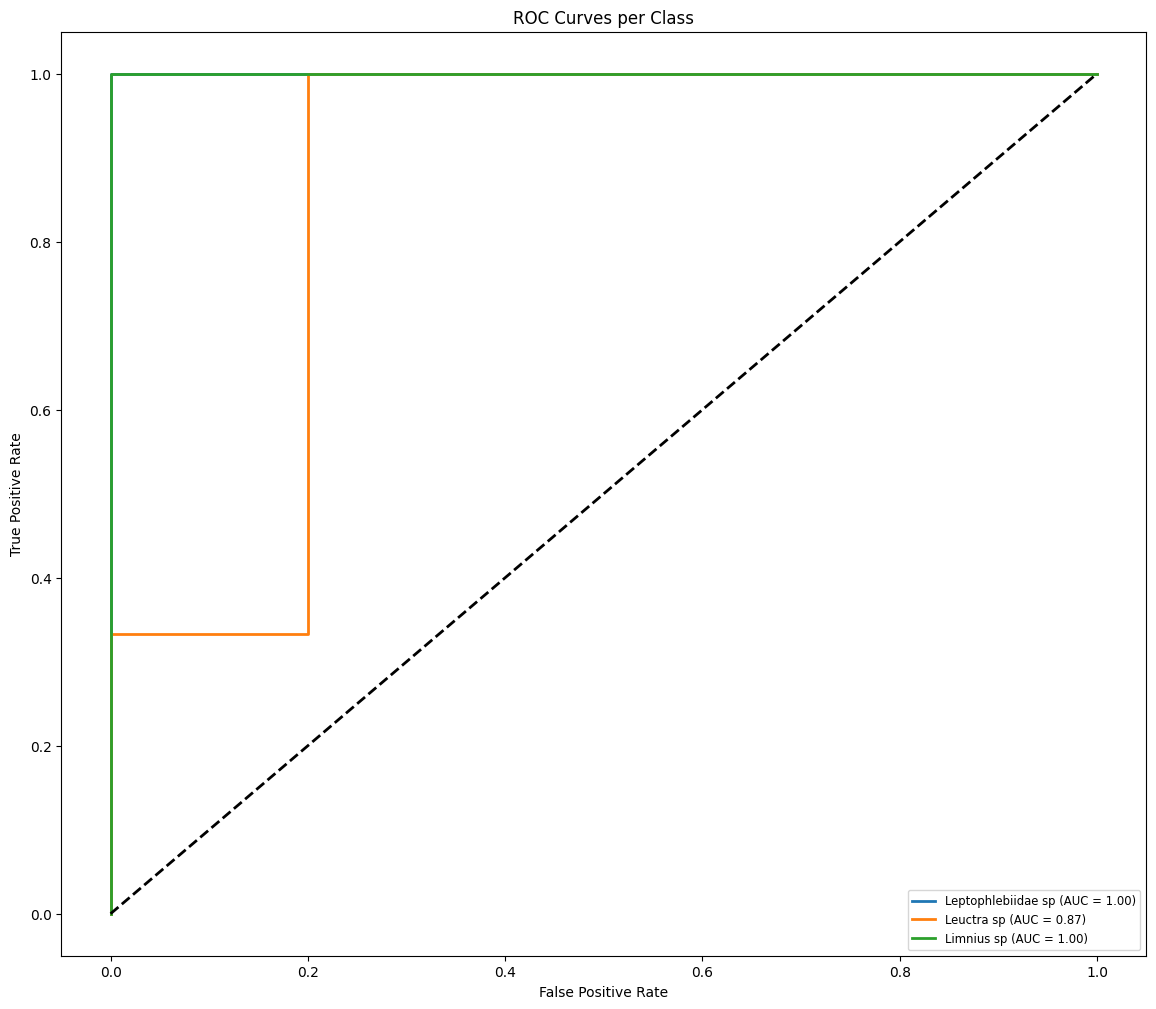

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf

# Aggregate true labels and predictions from validation dataset
y_true = []
y_pred = []
y_score = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall and F1-score
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'  # options: 'micro', 'macro', None...
)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# ROC Curve and AUC for multi-class
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Class')
plt.legend(loc='lower right', fontsize='small')
plt.show()


In [ ]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

# Ensure IMG_SIZE is treated as a tuple for this function
_target_img_size = (IMG_SIZE, IMG_SIZE) if not isinstance(IMG_SIZE, tuple) else IMG_SIZE

def load_and_preprocess_image(img_path, img_size=_target_img_size):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Running inference on images from 'test_images' folder...
No images found in '/content/drive/MyDrive/Colab_Notebooks/Week_7_Colab/Three insect species'. Please add some images and rerun.


**Evaluation Report**
* Show performance comparison of three models (MobileNet, EfficientNet, VisionTransformer Models) in terms of their performance metrics


*  Confusion Matrix screenshots,
*  precision, recall, F1-measure table
* ROC curve screenshots.


4. Build transfer learning model with MobileNet, EfficientNet and Vision Transformer Model pretrained on ImageNet
5. Train, evaluate, and predict on new images

**Performance Comparison**

MobileNet:
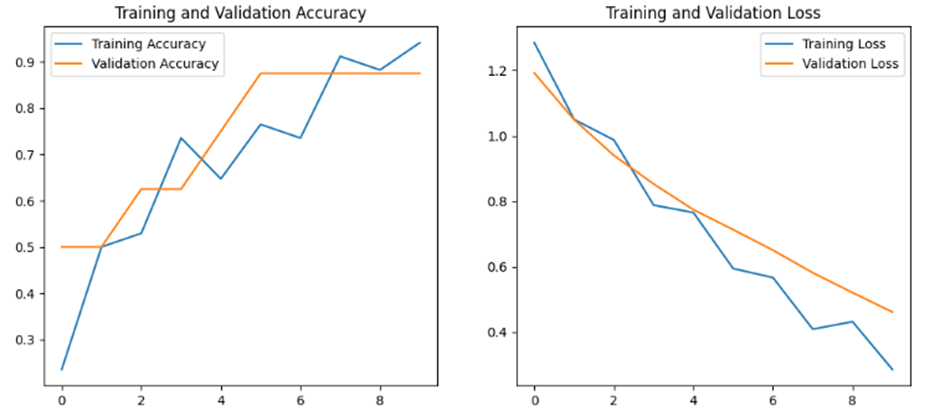

EfficientNet:
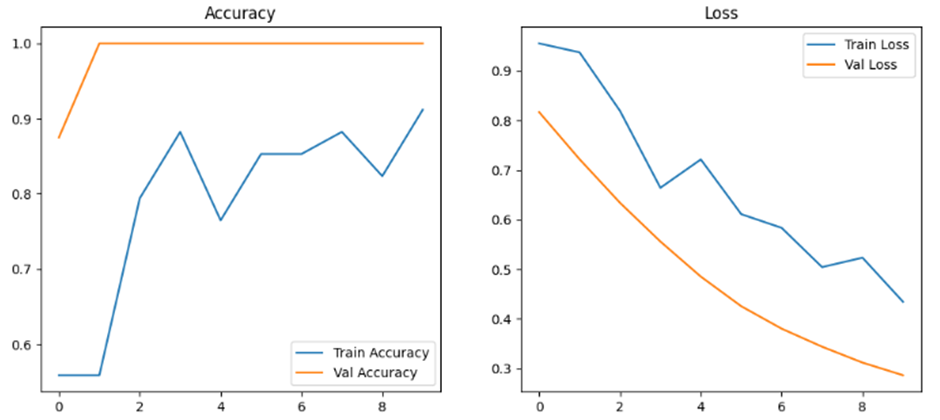
Transformer model:
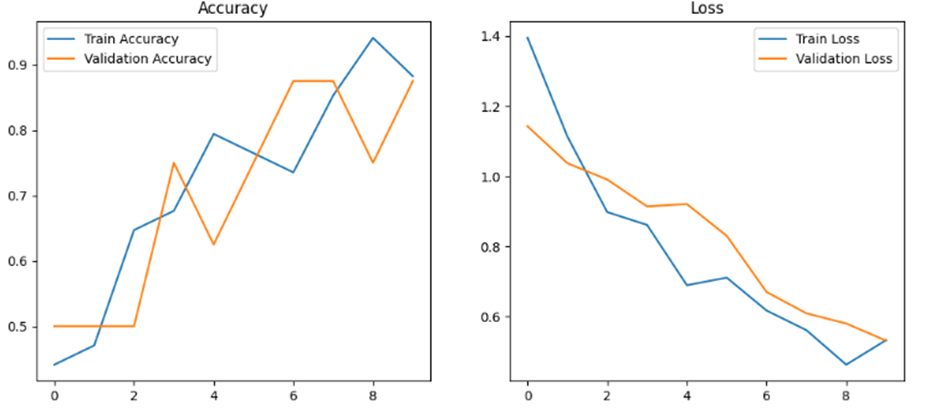

All the models were exceptionally accurate. The key differences between the three models were their adaptability. For general performance, I would choose MobileNet.

Mobilenet was the most consistent. It's train and validation accuracy closely followed each other as it adaped over the sets of enochs.

Efficientnet was incredibly unique. the validation accuracy was almost consistently perfect, but the training accuracy was low, and imporved slowly when compared to the other models. The difference between training and validation can be clearly seen through these graphs.

The transformer model started incredibly weak. It has incredibly low train and val accuracy, and high train and val loss at the start, and similarly to Efficientnet, it took a long time to improve on it's accuracy.

The greatest performer of them all was Mobilenet as it proved its consistency in these tests.